<a href="https://colab.research.google.com/github/ssamatyya1/roblox/blob/main/roblox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from matplotlib import font_manager

In [ ]:
df = pd.read_csv("roblox_games.csv")
df.head()

,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
0,#1,Blox Fruits,"483,372","41,346,317,182","13,574,097","8,521,670","676,846",92.64
1,#2,Brookhaven 🏡RP,"474,141","55,635,148,446","22,117,653","6,108,763","955,845",86.47
2,#3,Dress To Impress 💜,"297,764","3,876,511,994","3,182,036","2,042,092","188,403",91.55
3,#4,PETS GO! ✨ [NEW],"172,411","145,691,211","199,254","275,267","20,140",93.18
4,#5,Murder Mystery 2,"159,531","18,310,453,247","19,306,585","8,001,198","786,705",91.05


Просто вывод информации о бд

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        1000 non-null   object 
 1   Name        1000 non-null   object 
 2   Active      1000 non-null   object 
 3   Visits      1000 non-null   object 
 4   Favourites  1000 non-null   object 
 5   Likes       1000 non-null   object 
 6   Dislikes    1000 non-null   object 
 7   Rating      1000 non-null   float64
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


,Rating
count,1000.00000
mean,84.10001
std,11.12230
min,25.55000
25%,79.49500
50%,86.83000
75%,91.99250
max,98.59000


Очистка данных:

In [ ]:
# приведение названий столбцов к нижнему регистру
df.columns = df.columns.str.lower()

# список числовых столбцов
numeric_cols = ['rank', 'active', 'visits', 'favourites', 'likes', 'dislikes', 'rating']

# приводим все числовые столбцы к строкам и очищаем
for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)          # гарантируем строковый тип
        .str.replace('#', '', regex=False)
        .str.replace(',', '', regex=False)
    )

# преобразуем в числа
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# удаляем строки с NaN
df = df.dropna()

# приводим к int
df[numeric_cols] = df[numeric_cols].astype(int)

df['name'] = df['name'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

Создается новая метрика

In [ ]:
df['like_ratio'] = df['likes'] / (df['likes'] + df['dislikes'])

Коды для визуализации:

/tmp/ipython-input-870055063.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_visits, x='visits', y='name', palette=custom_colors)
/tmp/ipython-input-870055063.py:30: UserWarning: 
The palette list has fewer values (3) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=top_visits, x='visits', y='name', palette=custom_colors)


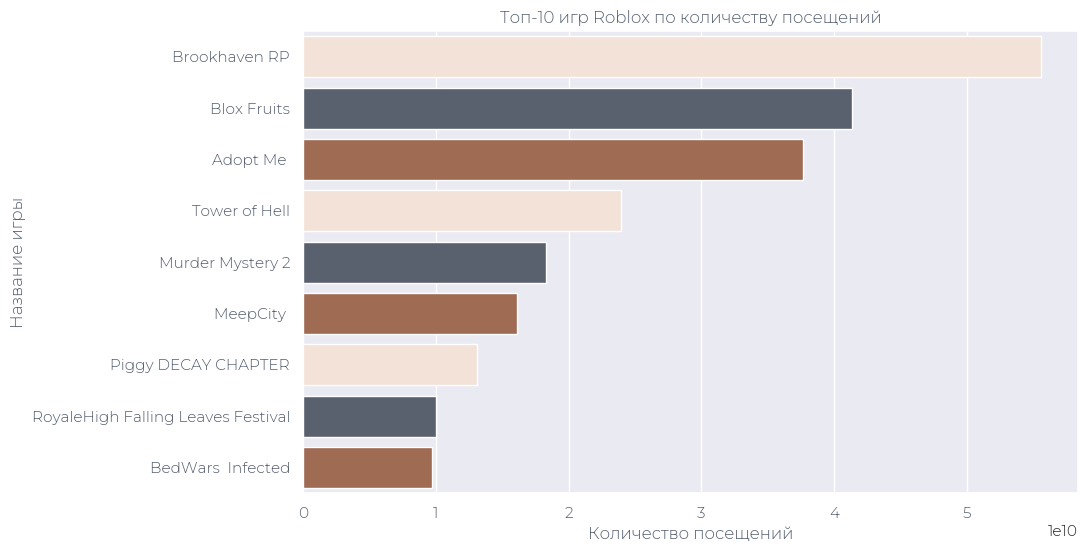

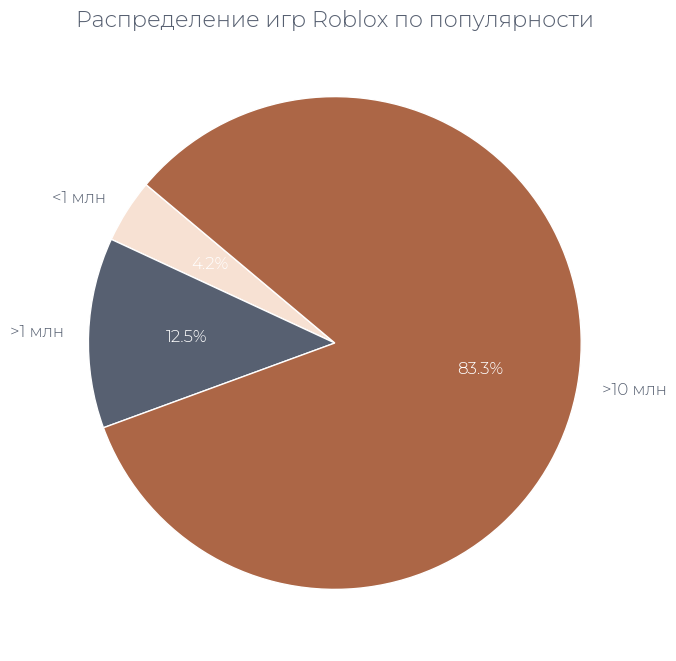

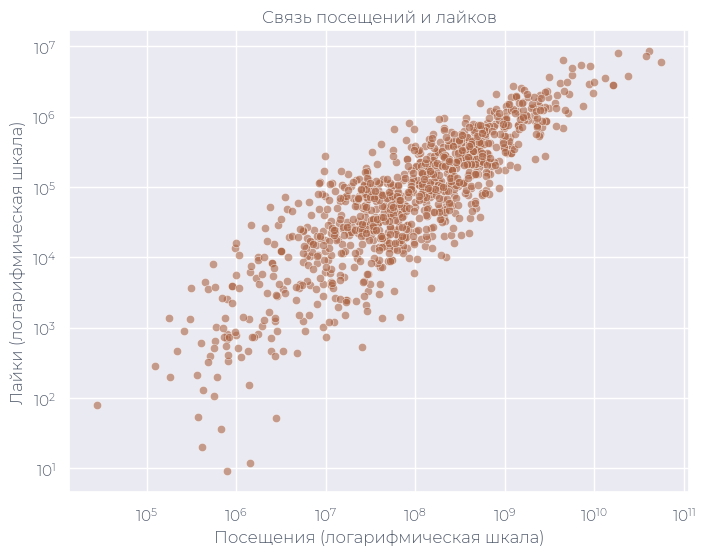

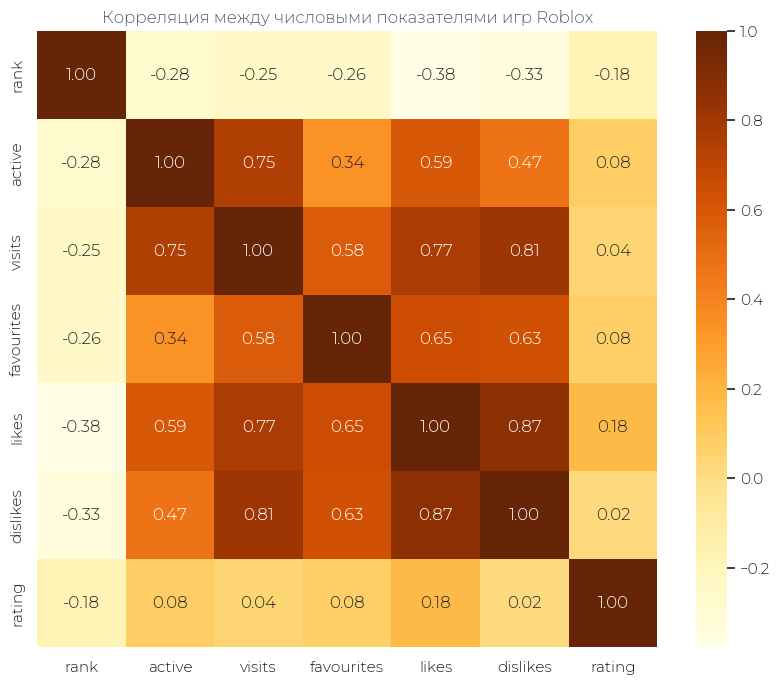

In [ ]:

sns.set_theme(
    style="darkgrid",
    font="sans-serif"
)

font_path = "/content/Montserrat-Light.ttf"

font_manager.fontManager.addfont(font_path)

plt.rcParams.update({
    "font.family": "Montserrat",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "regular"
})

sns.set_theme(style="darkgrid", font="Montserrat")

custom_colors = ["#F7E1D3", "#576071", "#AC6646"]
sns.set_palette(custom_colors)

# 1. Топ-10 игр по посещениям
top_visits = df.sort_values('visits', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_visits, x='visits', y='name', palette=custom_colors)
plt.title("Топ-10 игр Roblox по количеству посещений", color="#576071")
plt.xlabel("Количество посещений", color="#576071")
plt.ylabel("Название игры", color="#576071")
plt.xticks(color="#576071")
plt.yticks(color="#576071")
plt.show()

bins = [0, 1_000_000, 10_000_000, df['visits'].max()]
labels = ['<1 млн', '>1 млн', '>10 млн']
df['visits_category'] = pd.cut(df['visits'], bins=bins, labels=labels, include_lowest=True)

category_counts = df['visits_category'].value_counts().sort_index()

# Круговая диаграмма с белыми процентами
plt.figure(figsize=(8, 8))

def make_autopct(values):
    def my_autopct(pct):
        return f'{pct:.1f}%'
    return my_autopct

wedges, texts, autotexts = plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct=make_autopct(category_counts),
    colors=custom_colors,
    startangle=140,
    textprops={'color':'#576071', 'fontsize':12}

for autotext in autotexts:
    autotext.set_color('white')

plt.title("Распределение игр Roblox по популярности", color="#576071", fontsize=16)
plt.show()

# 3. Scatter: посещения vs лайки, другой цвет
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='visits', y='likes', alpha=0.6, color="#AC6646")
plt.xscale('log')
plt.yscale('log')
plt.title("Связь посещений и лайков", color="#576071")
plt.xlabel("Посещения (логарифмическая шкала)", color="#576071")
plt.ylabel("Лайки (логарифмическая шкала)", color="#576071")
plt.xticks(color="#576071")
plt.yticks(color="#576071")
plt.show()

# 4. Heatmap корреляции числовых столбцов
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlOrBr", cbar=True)
plt.title("Корреляция между числовыми показателями игр Roblox", color="#576071")
plt.show()